# Método de la potencia: cálculo de autovalores y velocidad de convergencia

Este proyecto implementa el **método de la potencia** para aproximar el autovalor de mayor módulo de una matriz, y estudia empíricamente en qué casos conviene usarlo según las propiedades de la matriz.

Se comparan 4 matrices con "dominancia diagonal" creciente y se analiza:

1. Qué tan rápido converge el método en cada caso.
2. Por qué la velocidad de convergencia depende de la relación entre el segundo y el primer autovalor de mayor módulo (λ₂/λ₁).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

%matplotlib inline

## 1. Implementación del método de la potencia

Dada una matriz A y un número de iteraciones k, el método parte de un vector aleatorio y lo multiplica repetidamente por A, normalizando en cada paso. La aproximación al autovalor en cada iteración se obtiene con el **cociente de Rayleigh**: `(vᵀAv) / (vᵀv)`.

In [2]:
def metodo_potencia(A, k):
    """
    Aplica k iteraciones del método de la potencia sobre la matriz A,
    partiendo de un vector aleatorio, y devuelve un array con la
    aproximación al autovalor de mayor módulo obtenida en cada paso
    (cociente de Rayleigh).
    """
    autovalores = np.zeros(k)
    v = np.random.rand(A.shape[0])
    for i in range(k):
        v = (A @ v) / np.linalg.norm(A @ v)
        autovalores[i] = (v.T @ A @ v) / (v.T @ v)
    return autovalores

In [3]:
# Validación contra np.linalg.eigvals en una matriz chica y conocida
mat_prueba = np.array([[-2., 0., 0.], [0., -5., 6.], [0., -3., 4.]])
aprox = metodo_potencia(mat_prueba, 200)[-1]
exacto = sorted(np.linalg.eigvals(mat_prueba), key=abs)[-1]

print(f"Aproximación (método de la potencia): {aprox:.6f}")
print(f"Valor exacto (np.linalg.eigvals):     {exacto.real:.6f}")

Aproximación (método de la potencia): -2.000000
Valor exacto (np.linalg.eigvals):     -2.000000


## 2. Comparación entre distintos tipos de matrices

Se generan 4 matrices de 100×100 con dominancia diagonal creciente:

- **A:** matriz aleatoria (no simétrica)
- **B:** matriz simétrica aleatoria
- **C:** B + 100 en la diagonal
- **D:** B + 1000 en la diagonal

La idea es ver cómo cambia la velocidad de convergencia a medida que la diagonal "domina" cada vez más a la matriz.

In [4]:
def generar_matrices(n):
    """
    Genera 4 matrices de n x n con dominancia diagonal creciente:
      A: matriz aleatoria (no simétrica)
      B: matriz simétrica aleatoria
      C: B + 100 en la diagonal
      D: B + 1000 en la diagonal
    """
    A = np.random.rand(n, n)
    B = np.triu(A) + np.triu(A).T
    C = B + 100 * np.eye(n)
    D = B + 1000 * np.eye(n)
    return A, B, C, D


N = 100
ITERACIONES = 100
NOMBRES = ["A (aleatoria)", "B (simétrica)", "C (B + 100·I)", "D (B + 1000·I)"]

matrices = generar_matrices(N)
trayectorias = [metodo_potencia(m, ITERACIONES) for m in matrices]

for nombre, tray in zip(NOMBRES, trayectorias):
    print(f"{nombre}: valor final aproximado = {tray[-1]:.4f}")

A (aleatoria): valor final aproximado = 49.7611
B (simétrica): valor final aproximado = 50.4967
C (B + 100·I): valor final aproximado = 150.4967
D (B + 1000·I): valor final aproximado = 1050.4955


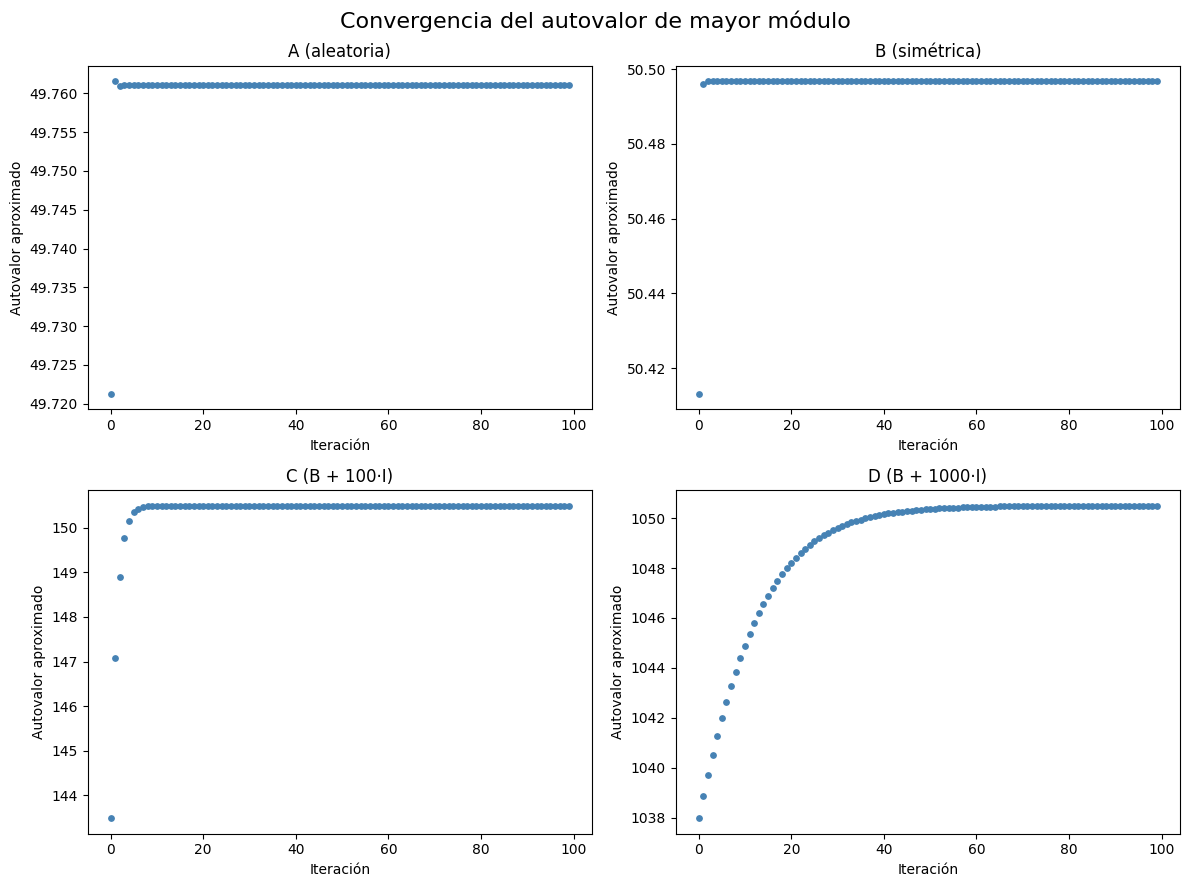

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, nombre, tray in zip(axes.flat, NOMBRES, trayectorias):
    ax.scatter(range(ITERACIONES), tray, color="steelblue", s=15)
    ax.set_xlabel("Iteración")
    ax.set_ylabel("Autovalor aproximado")
    ax.set_title(nombre)
fig.suptitle("Convergencia del autovalor de mayor módulo", fontsize=16)
plt.tight_layout()
plt.show()

**Observaciones:**

- Para las matrices **A** y **B** el método converge en pocas iteraciones.
- Para **C** y **D** la convergencia es notablemente más lenta, y se hace más lenta cuanto mayor es el valor sumado en la diagonal.
- Esto tiene una explicación algebraica directa: si B tiene autovalores λ, entonces B + x·I tiene autovalores λ + x. Al sumar una constante grande en la diagonal, el autovalor dominante crece pero también se acerca proporcionalmente al segundo autovalor — es decir, la relación λ₂/λ₁ se acerca a 1, y esa relación es justamente la que determina la velocidad de convergencia del método.

## 3. Análisis del error y velocidad de convergencia teórica

In [6]:
def autovalores_extremos(m):
    """Devuelve (lambda_1, lambda_2): los dos autovalores de mayor módulo."""
    vals = sorted(np.abs(np.linalg.eigvals(m)))
    return vals[-1], vals[-2]


def error_por_iteracion(m, aproximaciones, eps=1e-16):
    """log(|lambda_1 - aproximación|) en cada iteración."""
    lambda_1, _ = autovalores_extremos(m)
    return np.log(np.abs(lambda_1 - aproximaciones) + eps)


errores = [error_por_iteracion(m, tray) for m, tray in zip(matrices, trayectorias)]

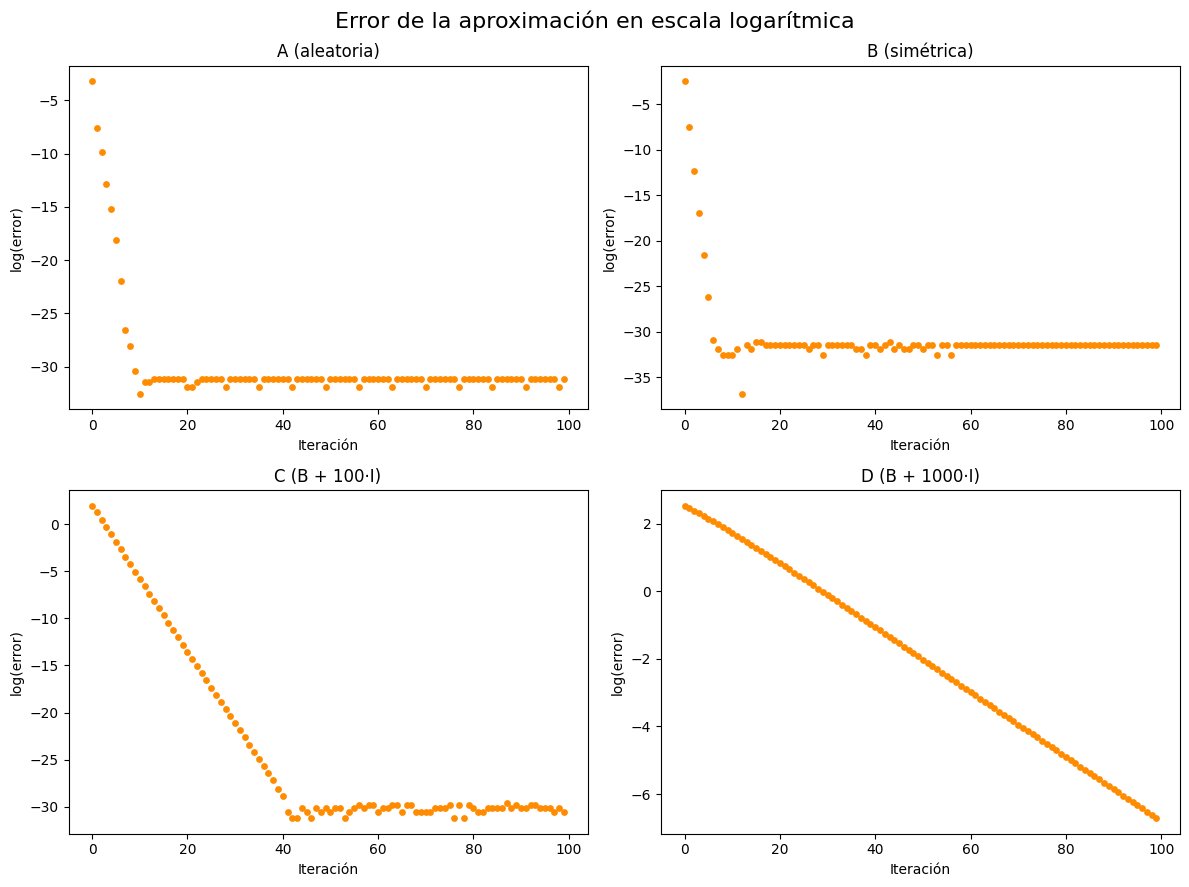

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, nombre, e in zip(axes.flat, NOMBRES, errores):
    ax.scatter(range(ITERACIONES), e, color="darkorange", s=15)
    ax.set_xlabel("Iteración")
    ax.set_ylabel("log(error)")
    ax.set_title(nombre)
fig.suptitle("Error de la aproximación en escala logarítmica", fontsize=16)
plt.tight_layout()
plt.show()

La teoría predice que el error se multiplica en cada paso, aproximadamente, por (λ₂/λ₁)². Eso implica que `log(error)` debería seguir una recta con pendiente ≈ `2·log(λ₂/λ₁)`. Comparamos esa recta teórica contra el error medido en cada caso.

A (aleatoria): pendiente teórica = -5.7138
B (simétrica): pendiente teórica = -4.2245
C (B + 100·I): pendiente teórica = -0.6990
D (B + 1000·I): pendiente teórica = -0.0863


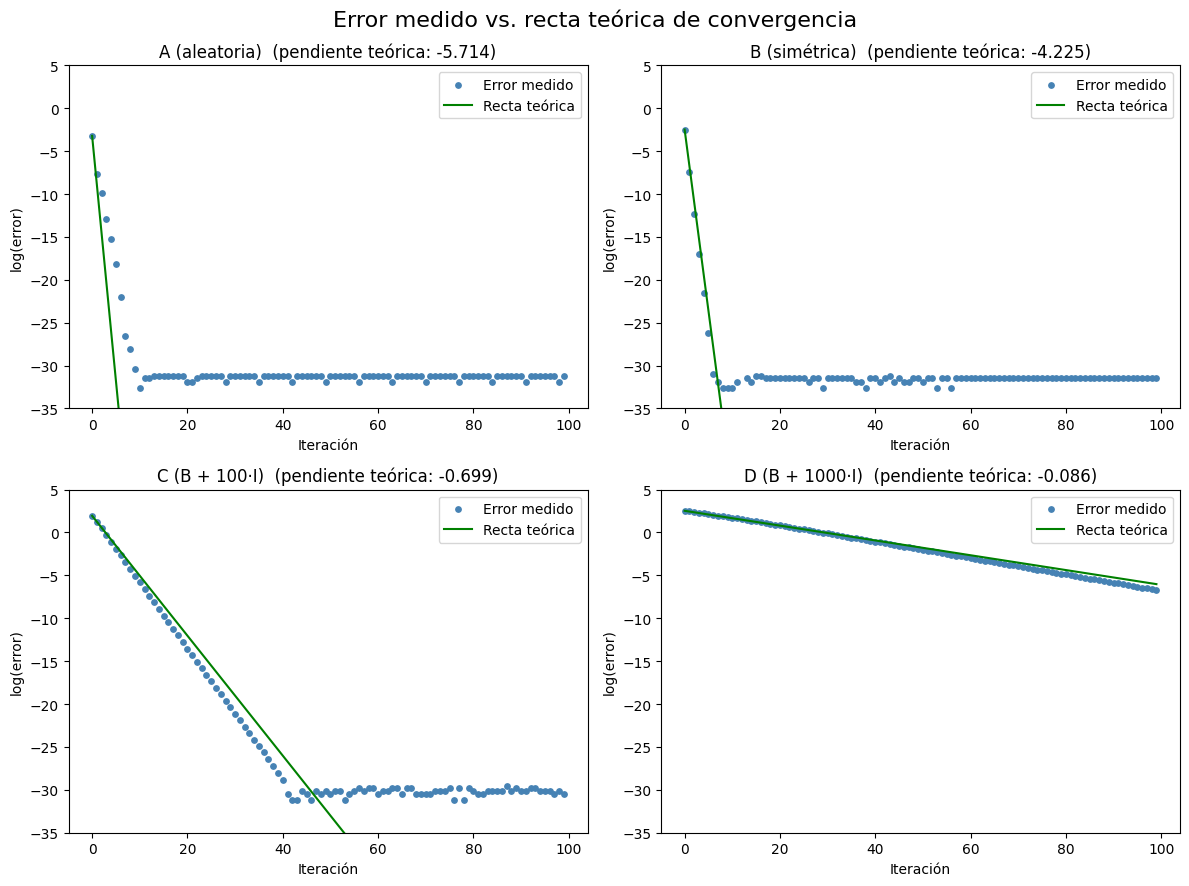

In [8]:
def recta_teorica(m, error_inicial, n_iter):
    lambda_1, lambda_2 = autovalores_extremos(m)
    pendiente = 2 * np.log(lambda_2 / lambda_1)
    x = np.arange(n_iter)
    return pendiente, pendiente * x + error_inicial


fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, nombre, m, e in zip(axes.flat, NOMBRES, matrices, errores):
    pendiente, recta = recta_teorica(m, e[0], ITERACIONES)
    ax.scatter(range(ITERACIONES), e, color="steelblue", s=15, label="Error medido")
    ax.plot(range(ITERACIONES), recta, color="green", label="Recta teórica")
    ax.set_xlabel("Iteración")
    ax.set_ylabel("log(error)")
    ax.set_ylim([-35, 5])
    ax.set_title(f"{nombre}  (pendiente teórica: {pendiente:.3f})")
    ax.legend()
fig.suptitle("Error medido vs. recta teórica de convergencia", fontsize=16)
plt.tight_layout()
plt.show()

for nombre, m, e in zip(NOMBRES, matrices, errores):
    pendiente, _ = recta_teorica(m, e[0], ITERACIONES)
    print(f"{nombre}: pendiente teórica = {pendiente:.4f}")

## 4. Conclusiones

- El método de la potencia converge más rápido cuanto mayor es, en valor absoluto, la pendiente de la recta de error — y esa pendiente depende directamente de qué tan separados están el primer y el segundo autovalor (λ₁ y λ₂).
- Sumar una constante grande en la diagonal (matrices C y D) no solo desplaza los autovalores, sino que además acerca proporcionalmente λ₂ a λ₁, lo que ralentiza la convergencia — el caso más extremo es la matriz D, donde el método tarda visiblemente más en converger que en A o B.
- En términos prácticos: el método de la potencia es más conveniente cuando el autovalor dominante está bien separado del resto. Si los dos autovalores más grandes están muy próximos, hacen falta muchas más iteraciones para obtener una buena aproximación — o conviene recurrir a otro método (por ejemplo, con deflación o shifts).